### Astrostatistics lectrure 2

#### Kicking horses

0.61


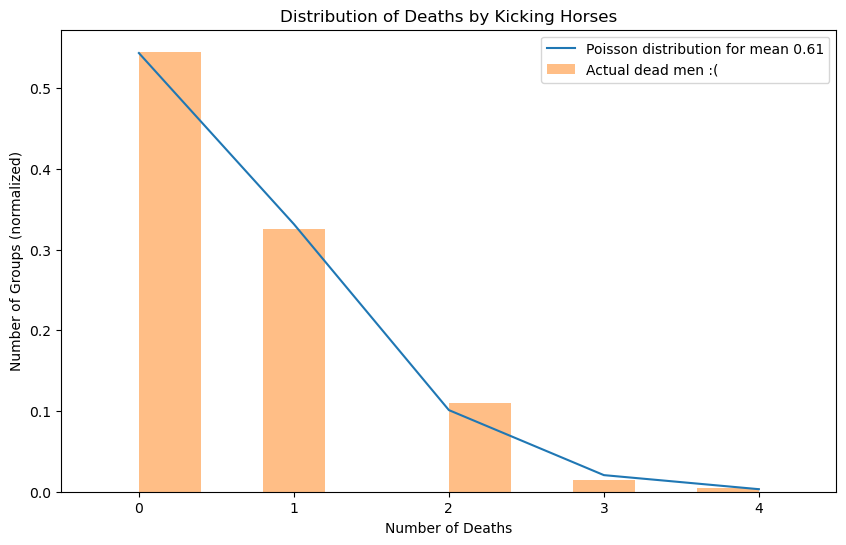

In [3]:
#Kicking horses 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
#first we import our statistics, so the number of groups and the number of deaths by horses 
Dead=[0,1,2,3,4]
groups=[109, 65, 22, 3, 1]
#It's basically a counting exp. so Poisson distribution
Mean=np.average(Dead, weights=groups) #estimate the mean of our dead men, weighted on the number of groups
print(Mean)
dist = poisson(Mean) #create a distribution with the mean 
weights = np.array(groups) / sum(groups) #normalize the weights for the histogram 

plt.figure(figsize=(10,6)) #set the size of the plot
plt.plot(Dead, dist.pmf(Dead), label=f'Poisson distribution for mean {Mean}') #plot the distribution
plt.hist(Dead, weights=weights, alpha=0.5, label='Actual dead men :(') 
plt.xlabel('Number of Deaths')
plt.xlim(-0.5, 4.5)
plt.ylabel('Number of Groups (normalized)')
plt.title('Distribution of Deaths by Kicking Horses')
plt.legend()
plt.show()


#### Integral calculation

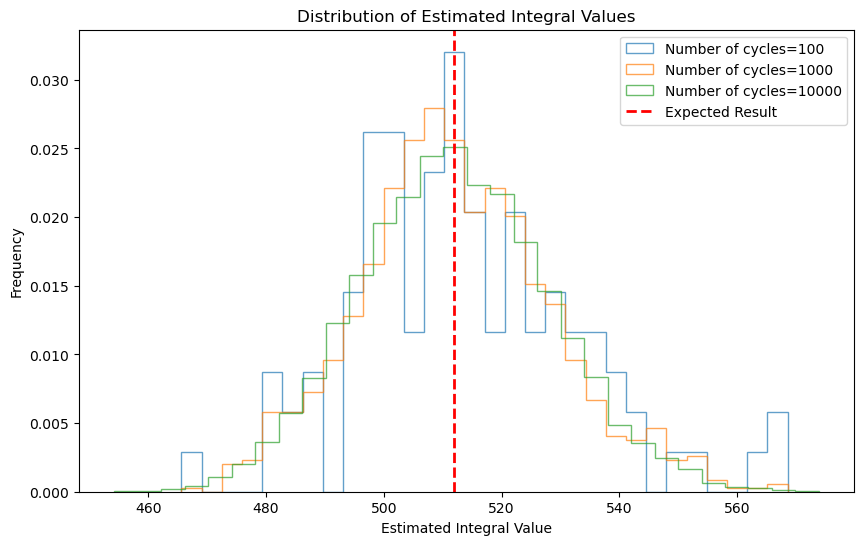

In [ ]:
# Calculating a very bad integral using monte carlo method

def function(x, mean, sigma): #corrected function to be evaluated with intervals sampled from a half gaussian distribution
    return np.exp((mean-2*mean*x)/2*sigma**2)*sigma*np.sqrt(2*np.pi)*x**3/2

#generate random samples from a half Gaussian distribution
def half_gaussian_samples(mean, sigma, size):
    samples = np.random.normal(loc=mean, scale=sigma, size=size)
    return samples[samples >= 0] #keep only the non-negative samples

i=0
N_array=[100, 1000, 10000]
integral_results = []

plt.figure(figsize=(10,6))

#gaussian centered in 0 with unitary variance, sampled only for positive values
for N in N_array:    
    while i<N: 
        mean = 0
        sigma = 4
        num_samples = 10000
        samples = half_gaussian_samples(mean, sigma, num_samples)
        #print(samples)
        results = function(samples, mean, sigma)
        i=i+1
        integral_estimate = np.mean(results) #estimate the integral as the mean of the function values
        integral_results.append(integral_estimate)
    expected_result = 2*sigma**4
    #print(f"Estimated integral: {integral_results}")    
    plt.hist(integral_results, bins=30, alpha=0.7, label=f'Number of cycles={N}', density=True, histtype='step')
    variance = 
#print(f"Expected result: {expected_result}")

plt.axvline(expected_result, color='red', linestyle='dashed', linewidth=2, label='Expected Result')
plt.xlabel('Estimated Integral Value')
plt.ylabel('Frequency')
plt.title('Distribution of Estimated Integral Values')
plt.legend()
plt.show()